### 라이브러리 설치 및 Import

In [30]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# =========================================================
# 스타벅스 공식 컬러 팔레트
# =========================================================
SB_DEEP_GREEN = '#1E3932'   # 가장 어두운 초록
SB_GREEN = '#006241'        # 공식 스타벅스 그린
SB_LIGHT_GREEN = '#D4E9E2'  # 연한 초록
SB_GOLD = '#CBA258'         # 골드
SB_GREY = '#A2AAAD'         # 회색
SB_BLACK = '#27251F'        # 텍스트용 블랙

sns.set_style("whitegrid")

# =========================================================
# 폰트 설정
# - Windows면 맑은 고딕
# - Mac이면 AppleGothic
# =========================================================
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['text.color'] = SB_BLACK
plt.rcParams['axes.labelcolor'] = SB_BLACK
plt.rcParams['xtick.color'] = SB_BLACK
plt.rcParams['ytick.color'] = SB_BLACK



print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


## 시각화

In [31]:
# =========================================================
# 데이터 불러오기
# =========================================================
df = pd.read_csv('../../Data/merged_df_260325.csv')

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 306137 entries, 0 to 306136
Data columns (total 26 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   person            306137 non-null  str    
 1   event             306137 non-null  str    
 2   time              306137 non-null  int64  
 3   offer_id          167184 non-null  str    
 4   amount            138953 non-null  float64
 5   bonus_reward      33182 non-null   float64
 6   time_days         306137 non-null  int64  
 7   gender            306137 non-null  str    
 8   age               272388 non-null  float64
 9   customer_id       306137 non-null  str    
 10  became_member_on  306137 non-null  str    
 11  income            272388 non-null  float64
 12  income_missing    306137 non-null  int64  
 13  age_missing       306137 non-null  int64  
 14  reward            167184 non-null  float64
 15  difficulty        167184 non-null  float64
 16  duration          167184 non-nu

In [33]:
df.tail(50)

,person,event,time,offer_id,amount,bonus_reward,time_days,gender,age,customer_id,became_member_on,income,income_missing,age_missing,reward,difficulty,duration,web,email,mobile,social,offer_label,event_order,is_received,receive_seq,order_label
306087,fffad4f4828548d1b5583907f2e9906b,viewed,6,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,1,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,1,0,1.0,True
306088,fffad4f4828548d1b5583907f2e9906b,completed,36,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0,2,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,2,0,1.0,True
306089,fffad4f4828548d1b5583907f2e9906b,received,408,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,18,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,0,1,2.0,True
306090,fffad4f4828548d1b5583907f2e9906b,viewed,510,f19421c1d4aa40978ebb69ca19b0e20d,NaN,NaN,22,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,1,0,2.0,True
306091,fffad4f4828548d1b5583907f2e9906b,completed,516,f19421c1d4aa40978ebb69ca19b0e20d,NaN,5.0,22,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,bogo_4,2,0,2.0,True
306092,fffad4f4828548d1b5583907f2e9906b,transaction,36,NaN,6.97,NaN,2,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN
306093,fffad4f4828548d1b5583907f2e9906b,transaction,66,NaN,2.95,NaN,3,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN
306094,fffad4f4828548d1b5583907f2e9906b,transaction,84,NaN,10.44,NaN,4,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN
306095,fffad4f4828548d1b5583907f2e9906b,transaction,120,NaN,6.26,NaN,6,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN
306096,fffad4f4828548d1b5583907f2e9906b,transaction,198,NaN,5.63,NaN,9,M,34.0,fffad4f4828548d1b5583907f2e9906b,2017-01-23,34000.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,NaN,NaN


> 1) informational event는 별도로 분리해야 함(informational 에서 completed로 연결되는 거래 X)
> 2) viewed 없이 completed 된 케이스도 분리해야 함

> 같은 고객 - 같은 오퍼 기준으로 received / viewed / completed 묶어서 보기!  
> 그래야 오퍼 퍼널 흐름 파악 가능  
> **오퍼 인스턴스(모두 묶은 1건 기준)** 로 정리!

In [34]:
# offer_label에서 offer_type 추출
# 예: bogo_3 → bogo / discount_2 → discount / informational_1 → informational
df['offer_type'] = df['offer_label'].str.split('_').str[0]

# customer_id, offer_id, time 기준으로 정렬
df = df.sort_values(['customer_id', 'offer_id', 'time']).reset_index(drop=True)

### 핵심 KPI

- 총 매출
- 총 거래 건수
- 거래당 평균 구매금액 = AOV
- 고객당 평균 구매금액 = 고객가치
- 채널별 고객 수
- 전체 고객 수

In [35]:
# 구매 데이터 추출
transactions = df[df['event'] == 'transaction'].copy()

# 핵심 KPI 계산
total_revenue = transactions['amount'].sum()                  # 총 매출
transaction_cnt = len(transactions)                           # 총 거래 건수
customer_cnt = df['customer_id'].nunique()                    # 전체 고객 수
buyer_cnt = transactions['customer_id'].nunique()             # 구매 고객 수

# 거래당 평균 구매금액(AOV)
aov = total_revenue / transaction_cnt if transaction_cnt > 0 else 0

# 고객당 평균 구매금액(전체 고객 기준)
customer_value = total_revenue / customer_cnt if customer_cnt > 0 else 0

# 구매 고객당 평균 구매금액(구매 고객 기준)
arppu = total_revenue / buyer_cnt if buyer_cnt > 0 else 0

# 평균 구매 빈도
avg_purchase_freq_all = transaction_cnt / customer_cnt if customer_cnt > 0 else 0
avg_purchase_freq_buyers = transaction_cnt / buyer_cnt if buyer_cnt > 0 else 0

print("=" * 60)
print("[핵심 KPI]")
print("=" * 60)
print(f"총 매출: ${total_revenue:,.2f}")
print(f"총 거래 건수: {transaction_cnt:,}건")
print(f"거래당 평균 구매 금액(AOV): ${aov:,.2f}")
print(f"고객당 평균 구매 금액(전체 고객 기준): ${customer_value:,.2f}")
print(f"고객당 평균 구매 금액(구매 고객 기준): ${arppu:,.2f}")
print(f"전체 고객 수: {customer_cnt:,}명")
print(f"구매 고객 수: {buyer_cnt:,}명")
print(f"평균 구매 빈도(전체 고객 기준): {avg_purchase_freq_all:,.2f}회")
print(f"평균 구매 빈도(구매 고객 기준): {avg_purchase_freq_buyers:,.2f}회")

[핵심 KPI]
총 매출: $1,775,451.97
총 거래 건수: 138,953건
거래당 평균 구매 금액(AOV): $12.78
고객당 평균 구매 금액(전체 고객 기준): $104.44
고객당 평균 구매 금액(구매 고객 기준): $107.10
전체 고객 수: 17,000명
구매 고객 수: 16,578명
평균 구매 빈도(전체 고객 기준): 8.17회
평균 구매 빈도(구매 고객 기준): 8.38회


### 채널별 고객 수(transaction과 분리)

In [36]:
# 채널별 고객 수
# - received 이벤트 기준으로 집계
# - transaction 행까지 섞이면 해석이 애매해지므로 발송 기준으로 보기
received_only = df[df['event'] == 'received'].copy()

channel_customer_summary = pd.DataFrame({
    '채널': ['web', 'email', 'mobile', 'social'],
    '고객수': [
        received_only.loc[received_only['web'] == 1, 'customer_id'].nunique(),
        received_only.loc[received_only['email'] == 1, 'customer_id'].nunique(),
        received_only.loc[received_only['mobile'] == 1, 'customer_id'].nunique(),
        received_only.loc[received_only['social'] == 1, 'customer_id'].nunique()
    ]
})

display(channel_customer_summary)

,채널,고객수
0,web,16916
1,email,16994
2,mobile,16980
3,social,16529


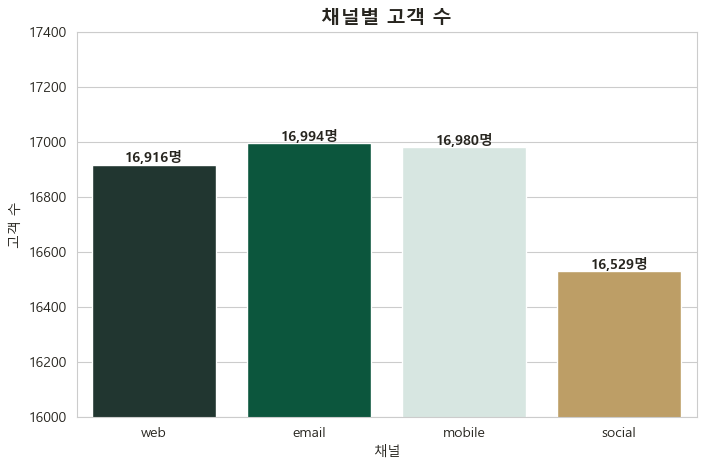

In [37]:
# 채널별 고객 수 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=channel_customer_summary,
    x='채널',
    y='고객수',
    palette=[SB_DEEP_GREEN, SB_GREEN, SB_LIGHT_GREEN, SB_GOLD]
)

for i, v in enumerate(channel_customer_summary['고객수']):
    ax.text(i, v, f"{int(v):,}명", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('채널별 고객 수', fontsize=14, fontweight='bold')
plt.xlabel('채널')
plt.ylabel('고객 수')
plt.ylim(16000, 17400)
plt.show()

### 오퍼 퍼널

> 퍼널은 3개로 분리

> **1) received → viewed → completed 3단계를 모두 거치는 오퍼에 대한 퍼널 (전략적 전환)**  
    - 대상: bogo, discount  
    - 핵심 KPI  
        - 열람율 = viewed / received  
        - 전략적 전환율 = viewed가 선행된 후의 completed / received  

> **2) received → completed 2단계만 거치는 오퍼에 대한 퍼널 (자발적/우연적 전환)**  
    - 대상: bogo, discount  
    - 여기서는 오퍼가 없어도 완료까지 수행하는 고객 군이므로 오퍼 낭비 대상이라고 생각  
          (굳이 오퍼 안해도 사먹으니까?)  
    - 핵심 KPI  
        - 낭비된 완료 수  
        - 낭비된 리워드 비율 = Viewed 없이 Completed 된 리워드 합계 / 전체 리워드 합계

> **3) informational 만 따로 뺀 퍼널**  
    - 대상: informational (received → viewed)  
    - 핵심 KPI  
        - viewed 이후 24시간 내에 transaction 발생 수  
        - viewed 이후 24시간 내 구매 전환율  
        - viewed 이후 24시간 내 평균 구매 금액  
        - viewed O vs viewed X 고객 세그먼트 분석  
        - 보상에 따른 매출 증대율 계산(오퍼를 완료한 사람들의 평균 결제액 - 정보 제공 후 24시간 내 매출 / 정보 제공 후 24시간 내 매출 )*100 ← duration * 24 시간 이내 발생한 결제를 분모로 잡으면 더 정확한 계산

### 오퍼 인스턴스 테이블

In [38]:
# 오퍼 인스턴스 테이블 만들기
# ---------------------------------------------------------
# 목적:
# - 같은 고객이 같은 offer_id를 여러 번 받을 수 있으므로 받은 1건 단위로 분석해야 함
# - 각 received 이벤트를 하나의 오퍼 인스턴스로 보고,
#   그 이후 유효기간(duration) 안에 viewed/completed가 있었는지 확인


# 발송(received) 이벤트만 추출
offer_received = df[df['event'] == 'received'].copy()

# 같은 고객이 같은 오퍼를 몇 번째 받았는지 순번 부여(receive_seq 컬럼 생성)
offer_received = offer_received.sort_values(['customer_id', 'offer_id', 'time']).copy()
offer_received['receive_seq'] = offer_received.groupby(['customer_id', 'offer_id']).cumcount() + 1

# 다음 동일 오퍼 수신 시점 계산
# - 같은 고객이 같은 offer_id를 또 받기 전까지만 현재 오퍼 인스턴스의 유효 범위로 본다
offer_received['next_received_time'] = offer_received.groupby(['customer_id', 'offer_id'])['time'].shift(-1)

# 원래 오퍼 만료 시점 = received_time + duration * 24시간
offer_received['offer_end_time'] = offer_received['time'] + offer_received['duration'] * 24

# 실제 분석 윈도우 종료 시점
# - 다음 오퍼를 다시 받기 전이 더 빠르면 거기까지
# - 아니면 원래 duration 종료 시점까지
offer_received['window_end_time'] = np.where(
    offer_received['next_received_time'].notna(),
    np.minimum(offer_received['offer_end_time'], offer_received['next_received_time']),
    offer_received['offer_end_time']
)

# 컬럼명 정리
offer_received = offer_received.rename(columns={'time': 'received_time'})

# 필요한 컬럼만 남김
offer_received = offer_received[
    [
        'customer_id', 'offer_id', 'offer_label', 'offer_type',
        'received_time', 'window_end_time', 'duration',
        'reward', 'difficulty',
        'web', 'email', 'mobile', 'social',
        'receive_seq'
    ]
].copy()

display(offer_received.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1
2,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1
4,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1
6,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1
9,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1


### 열람과 완료 이벤트를 위 오퍼 인스턴스에 붙이기

In [39]:
# 열람(viewed), 완료(completed) 이벤트 준비
offer_viewed = df[df['event'] == 'viewed'][['customer_id', 'offer_id', 'time']].copy()
offer_completed = df[df['event'] == 'completed'][['customer_id', 'offer_id', 'time', 'bonus_reward']].copy()

# 각 발송 건마다 열람 여부 붙이기
# ---------------------------------------------------------
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 열람 시점이 received_time 이후
# - 열람 시점이 window_end_time 이전
view_merge = offer_received.merge(
    offer_viewed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 안 본 경우도 분석해야 하므로 left join
    suffixes=('', '_view')
)

view_merge = view_merge[
    (view_merge['time'].isna()) |                                # 열람 기록이 아예 없거나(안 본 사람 계산)
    (
        (view_merge['time'] >= view_merge['received_time']) &    # 열람 시간이 오퍼를 받은 시점 이후이고,
        (view_merge['time'] <= view_merge['window_end_time'])    # 오퍼 유효기간 끝나는 시점 이전
    )
]

view_summary = (
    view_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        viewed=('time', lambda x: x.notna().any()),    # 유효한 열람 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_view_time=('time', 'min')                # 수신 건에 대해 가장 빠른 열람 시간을 저장
    )
)


# 각 발송 건마다 완료 여부 붙이기
# ---------------------------------------------------------
# 조건:
# - 같은 customer_id, 같은 offer_id
# - 완료 시점이 received_time 이후
# - 완료 시점이 window_end_time 이전
complete_merge = offer_received.merge(
    offer_completed,
    on=['customer_id', 'offer_id'],
    how='left',                        # 오퍼를 받았지만 완료 안 한 경우도 분석해야 하므로 left join
    suffixes=('', '_complete')
)

complete_merge = complete_merge[
    (complete_merge['time'].isna()) |                                  # 완료 기록이 아예 없거나(완료 안 한 사람 계산)
    (
        (complete_merge['time'] >= complete_merge['received_time']) &  # 완료 시간이 오퍼를 받은 시점 이후이고,
        (complete_merge['time'] <= complete_merge['window_end_time'])  # 오퍼 유효기간 끝나는 시점 이전
    )
]

complete_summary = (
    complete_merge.groupby(['customer_id', 'offer_id', 'receive_seq'], as_index=False)
    .agg(
        completed=('time', lambda x: x.notna().any()),    # 유효한 완료 기록이 하나라도 있으면 True, 하나도 없으면 False
        first_complete_time=('time', 'min'),              # 수신 건에 대해 가장 빠른 완료 시간을 저장
        bonus_reward_sum=('bonus_reward', 'max')          # 수신 건에서 발생한 bonus_reward 최대값(오퍼 1번 완료 시 1번 보상이므로 합계 구할 필요 X)
    )
)


### 오퍼 인스턴스 테이블 완성

In [40]:
# 오퍼 인스턴스 테이블 완성
offer_instance = (
    offer_received
    .merge(view_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
    .merge(complete_summary, on=['customer_id', 'offer_id', 'receive_seq'], how='left')
)

# 결측 처리
offer_instance['viewed'] = offer_instance['viewed'].fillna(False)
offer_instance['completed'] = offer_instance['completed'].fillna(False)
offer_instance['bonus_reward_sum'] = offer_instance['bonus_reward_sum'].fillna(0)


# 전략적 완료 / 우연적 완료 분류
# ---------------------------------------------------------
# 전략적 완료(effective_completed):
# - completed == True
# - viewed == True
# - first_view_time <= first_complete_time
#
# 우연적 완료(accidental_completed):
# - completed 이긴 한데, 전략적 완료는 아닌 경우
offer_instance['effective_completed'] = (
    offer_instance['completed'] &
    offer_instance['viewed'] &
    (offer_instance['first_view_time'] <= offer_instance['first_complete_time'])
)

offer_instance['accidental_completed'] = (
    offer_instance['completed'] &
    (~offer_instance['effective_completed'])
)

display(offer_instance.head())

,customer_id,offer_id,offer_label,offer_type,received_time,window_end_time,duration,reward,difficulty,web,email,mobile,social,receive_seq,viewed,first_view_time,completed,first_complete_time,bonus_reward_sum,effective_completed,accidental_completed
0,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,discount_4,discount,576,744.0,7.0,2.0,10.0,1.0,1.0,1.0,0.0,1,False,NaN,True,576.0,2.0,False,True
1,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,informational_1,informational,336,432.0,4.0,0.0,0.0,1.0,1.0,1.0,0.0,1,True,372.0,False,NaN,0.0,False,False
2,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,informational_2,informational,168,240.0,3.0,0.0,0.0,0.0,1.0,1.0,1.0,1,True,192.0,False,NaN,0.0,False,False
3,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,bogo_4,bogo,408,528.0,5.0,5.0,5.0,1.0,1.0,1.0,1.0,1,True,456.0,True,414.0,5.0,False,True
4,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,discount_3,discount,504,744.0,10.0,2.0,10.0,1.0,1.0,1.0,1.0,1,True,540.0,True,528.0,2.0,False,True


### 전략적 전환 퍼널

#### bogo / discount

In [41]:
# 전략적 전환 퍼널 대상 추출
# - bogo, discount만 포함
# - informational은 제외
conv_offer = offer_instance[offer_instance['offer_type'].isin(['bogo', 'discount'])].copy()

# 단계별 건수
received_cnt = len(conv_offer)
viewed_cnt = conv_offer['viewed'].sum()
completed_cnt = conv_offer['completed'].sum()
effective_completed_cnt = conv_offer['effective_completed'].sum()
accidental_completed_cnt = conv_offer['accidental_completed'].sum()

# 핵심 KPI
view_rate = viewed_cnt / received_cnt if received_cnt > 0 else 0
strategic_conversion_rate = effective_completed_cnt / received_cnt if received_cnt > 0 else 0
view_to_effective_rate = effective_completed_cnt / viewed_cnt if viewed_cnt > 0 else 0

print("=" * 60)
print("[전략적 전환 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {received_cnt:,}건")
print(f"열람 수: {viewed_cnt:,}건")
print(f"완료 수(전체): {completed_cnt:,}건")
print(f"전략적 완료 수: {effective_completed_cnt:,}건")
print(f"우연적 완료 수: {accidental_completed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {view_rate:.2%}")
print(f"전략적 전환율 = 전략적 완료 / 발송: {strategic_conversion_rate:.2%}")
print(f"열람 후 전략적 완료율 = 전략적 완료 / 열람: {view_to_effective_rate:.2%}")

[전략적 전환 퍼널 KPI]
발송 수: 61,042건
열람 수: 46,685건
완료 수(전체): 33,163건
전략적 완료 수: 23,313건
우연적 완료 수: 9,850건
열람율 = 열람 / 발송: 76.48%
전략적 전환율 = 전략적 완료 / 발송: 38.19%
열람 후 전략적 완료율 = 전략적 완료 / 열람: 49.94%


> 열람율 = 76.48% → 발송된 bogo / discount 오퍼의 대략 3/4는 고객이 열람함  
→ 노출은 괜찮은 편  
전략적 전환율 = 38.19% → 전체 발송 대비 약 38%가 완료  
→ 오퍼 성과 괜찮음  
열람 후 전략적 완료율 = 49.94% → 오퍼를 한 번이라도 본 고객한테는 오퍼 효과 있음

#### 전략적 전환 퍼널 시각화

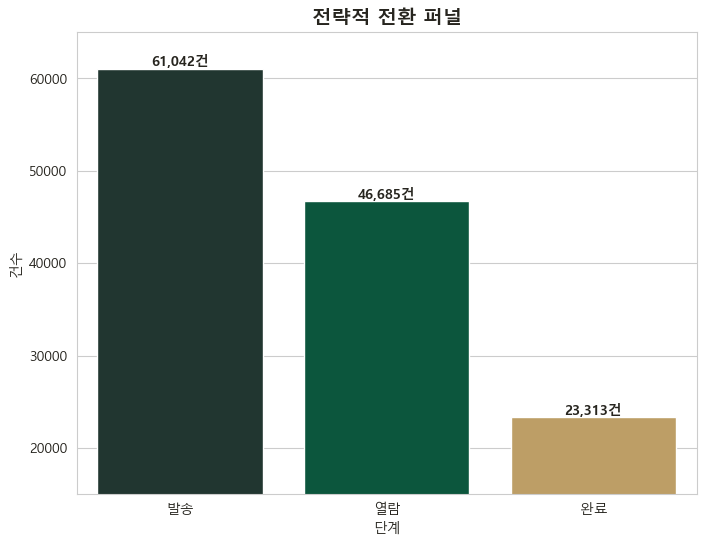

In [42]:
# 전략적 전환 퍼널 시각화
strategic_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람', '완료'],
    '건수': [received_cnt, viewed_cnt, effective_completed_cnt]
})

plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=strategic_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_DEEP_GREEN, SB_GREEN, SB_GOLD]
)

for i, v in enumerate(strategic_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('전략적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(15000, 65000)
plt.show()

### 우연적 전환 퍼널

#### bogo / discount

In [43]:
# 우연적 전환 KPI
# ---------------------------------------------------------
# 우연적 완료 = viewed 없이 completed 된 경우
# 리워드 낭비 비율 = Viewed 없이 Completed 된 reward 합 / 전체 completed 건의 reward 합
wasted_completed_cnt = accidental_completed_cnt

total_reward_paid = conv_offer.loc[conv_offer['completed'], 'reward'].sum()
wasted_reward_amt = conv_offer.loc[conv_offer['accidental_completed'], 'reward'].sum()
wasted_reward_rate = wasted_reward_amt / total_reward_paid if total_reward_paid > 0 else 0
wasted_reward_pct = wasted_reward_amt / wasted_completed_cnt if total_reward_paid > 0 else 0

print("=" * 60)
print("[우연적 전환 KPI]")
print("=" * 60)
print(f"낭비된 완료 수: {wasted_completed_cnt:,}건")
print(f"낭비된 리워드 금액: ${wasted_reward_amt:,.2f}")
print(f"낭비된 리워드 비율: {wasted_reward_rate:.2%}")
print(f"낭비된 리워드 평균 금액: ${wasted_reward_pct:.2f}")

[우연적 전환 KPI]
낭비된 완료 수: 9,850건
낭비된 리워드 금액: $48,287.00
낭비된 리워드 비율: 29.67%
낭비된 리워드 평균 금액: $4.90


> 낭비된 리워드 금액 = $48,287 → 원래 살 가능성이 높았던 고객에게도 보상이 많이 지급됨  
> 낭비된 리워드 비율 = 29.67% → 생각보다 view 없이 구매 완료까지 이어지는 고객 비율이 높음  
→ 이 부분을 개선하면 어떨까?

#### 우연적 전환 퍼널 시각화

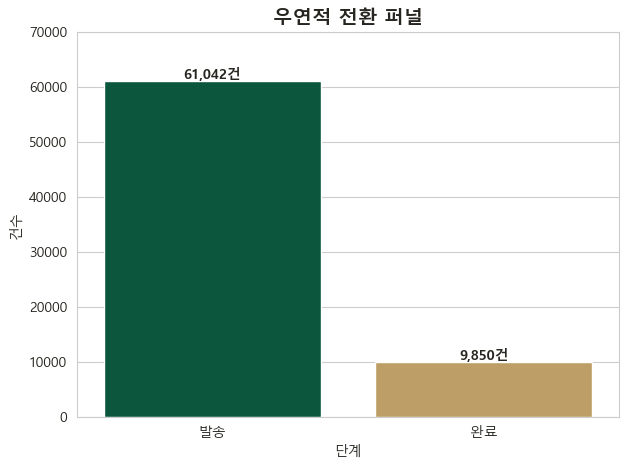

In [44]:
# 우연적 전환 퍼널 시각화
accidental_funnel_df = pd.DataFrame({
    '단계': ['발송', '완료'],
    '건수': [received_cnt, wasted_completed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=accidental_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(accidental_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('우연적 전환 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(0, 70000)
plt.show()

### informational 퍼널 및 24시간 내 구매 분석

#### informational 발송 → 열람 퍼널

In [45]:
# informational 오퍼만 추출
info_offer = offer_instance[offer_instance['offer_type'] == 'informational'].copy()

info_received_cnt = len(info_offer)
info_viewed_cnt = info_offer['viewed'].sum()
info_view_rate = info_viewed_cnt / info_received_cnt if info_received_cnt > 0 else 0

print("=" * 60)
print("[Informational 퍼널 KPI]")
print("=" * 60)
print(f"발송 수: {info_received_cnt:,}건")
print(f"열람 수: {info_viewed_cnt:,}건")
print(f"열람율 = 열람 / 발송: {info_view_rate:.2%}")

[Informational 퍼널 KPI]
발송 수: 15,235건
열람 수: 9,952건
열람율 = 열람 / 발송: 65.32%


> 열람율 = 65.32% → 단순 정보성 오퍼이지만 열람 비율 높은 편

#### informational 퍼널 시각화

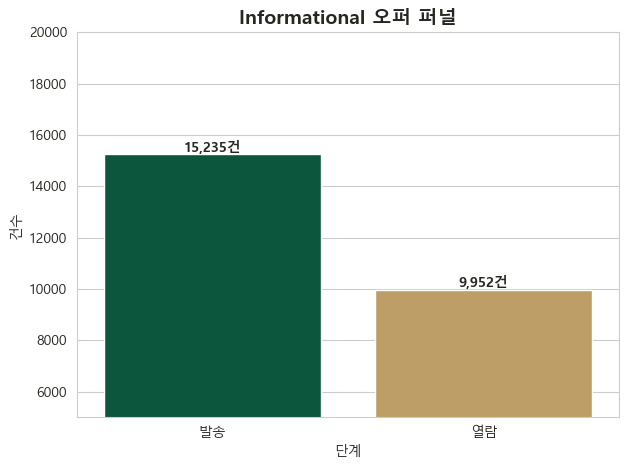

In [46]:
# informational 퍼널 시각화
info_funnel_df = pd.DataFrame({
    '단계': ['발송', '열람'],
    '건수': [info_received_cnt, info_viewed_cnt]
})

plt.figure(figsize=(7, 5))
ax = sns.barplot(
    data=info_funnel_df,
    x='단계',
    y='건수',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_funnel_df['건수']):
    ax.text(i, v, f"{int(v):,}건", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('Informational 오퍼 퍼널', fontsize=14, fontweight='bold')
plt.xlabel('단계')
plt.ylabel('건수')
plt.ylim(5000, 20000)
plt.show()

#### 열람 후 24시간 내 구매 분석

In [47]:
# informational 열람 이벤트만 추출
info_view_events = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
][['customer_id', 'offer_id', 'time']].copy()

info_view_events = info_view_events.rename(columns={'time': 'view_time'})

# transaction 데이터는 customer_id, time, amount만 사용
transactions_small = transactions[['customer_id', 'time', 'amount']].copy()
transactions_small = transactions_small.rename(columns={'time': 'txn_time'})


# 열람 이벤트와 구매 이력 연결
# ---------------------------------------------------------
# 같은 고객의 transaction을 모두 붙인 후,
# viewed 후 24시간 이내인지 여부를 체크
info_txn_merge = info_view_events.merge(
    transactions_small,
    on='customer_id',
    how='left'
)

info_txn_merge['txn_within_24h'] = (
    (info_txn_merge['txn_time'] >= info_txn_merge['view_time']) &
    (info_txn_merge['txn_time'] <= info_txn_merge['view_time'] + 24)
)


# viewed 1건 단위로 요약
# ---------------------------------------------------------
# viewed 1건마다:
# - 24시간 내 구매가 있었는지
# - 24시간 내 구매금액 합계가 얼마인지
info_24h_summary = (
    info_txn_merge.groupby(['customer_id', 'offer_id', 'view_time'], as_index=False)
    .agg(
        purchased_24h=('txn_within_24h', 'any'),
        revenue_24h=('amount', lambda x: x[info_txn_merge.loc[x.index, 'txn_within_24h']].sum())
    )
)

display(info_24h_summary.head())

,customer_id,offer_id,view_time,purchased_24h,revenue_24h
0,0009655768c64bdeb2e877511632db8f,3f207df678b143eea3cee63160fa8bed,372,False,0.0
1,0009655768c64bdeb2e877511632db8f,5a8bc65990b245e5a138643cd4eb9837,192,False,0.0
2,0011e0d4e6b944f998e987f904e8c1e5,3f207df678b143eea3cee63160fa8bed,6,False,0.0
3,0011e0d4e6b944f998e987f904e8c1e5,5a8bc65990b245e5a138643cd4eb9837,354,False,0.0
4,0020c2b971eb4e9188eac86d93036a77,5a8bc65990b245e5a138643cd4eb9837,660,False,0.0


In [48]:
info_24h_summary[info_24h_summary['purchased_24h'] == True].describe()

,view_time,revenue_24h
count,4254.000000,4254.000000
mean,364.005642,16.780646
std,192.295857,30.895251
min,0.000000,0.050000
25%,192.000000,4.352500
50%,408.000000,12.490000
75%,520.500000,22.355000
max,714.000000,725.990000


In [49]:
# informational 24시간 KPI 계산
info_24h_purchase_cnt = info_24h_summary['purchased_24h'].sum()
info_24h_conversion_rate = info_24h_purchase_cnt / info_viewed_cnt
info_24h_total_revenue = info_24h_summary['revenue_24h'].sum()
info_24h_avg_revenue = info_24h_total_revenue / info_24h_purchase_cnt

print("=" * 60)
print("[Informational 24시간 내 구매 KPI]")
print("=" * 60)
print(f"열람 후 24시간 내 transaction 발생 수: {info_24h_purchase_cnt:,}건")
print(f"열람 후 24시간 내 구매 전환율: {info_24h_conversion_rate:.2%}")
print(f"열람 후 24시간 내 총 구매 금액: ${info_24h_total_revenue:,.2f}")
print(f"열람 후 24시간 내 평균 구매 금액: ${info_24h_avg_revenue:,.2f}")

[Informational 24시간 내 구매 KPI]
열람 후 24시간 내 transaction 발생 수: 4,254건
열람 후 24시간 내 구매 전환율: 42.75%
열람 후 24시간 내 총 구매 금액: $71,384.87
열람 후 24시간 내 평균 구매 금액: $16.78


> 열람 후 24시간 내 구매 전환율 = 42.75%  
→ 단순 정보 제공이지만 구매 전환율이 꽤 나와서 의미 없는 오퍼는 아니다?  
→ 그렇지만 인과관계는 아님

#### informational 본 사람 vs 안 본 사람

> 본 사람: informational viewed 경험이 1번 이상 있는 고객  
안 본 사람: informational viewed 경험이 없는 고객

In [50]:
# 고객별 총 구매금액 테이블 만들기
customer_stats = (
    transactions.groupby('customer_id')['amount']
    .agg(['sum', 'count', 'mean'])
    .reset_index()
    .rename(columns={
        'sum': 'total_spend',
        'count': 'purchase_cnt',
        'mean': 'aov_customer'
    })
)

# 전체 고객을 기준으로 0원 구매 고객도 포함하기 위해
# customer_master를 만들어 left join 한 뒤 결측을 0으로 채워준다
customer_master = pd.DataFrame({'customer_id': df['customer_id'].unique()})

customer_stats = customer_master.merge(customer_stats, on='customer_id', how='left')
customer_stats[['total_spend', 'purchase_cnt', 'aov_customer']] = customer_stats[
    ['total_spend', 'purchase_cnt', 'aov_customer']
].fillna(0)


# informational 열람 경험 고객 표시
info_view_customer = df[
    (df['event'] == 'viewed') &
    (df['offer_type'] == 'informational')
]['customer_id'].unique()

customer_stats['info_viewed_flag'] = customer_stats['customer_id'].isin(info_view_customer)

# 그룹별 평균 비교
info_view_compare = (
    customer_stats.groupby('info_viewed_flag', as_index=False)
    .agg(
        고객수=('customer_id', 'nunique'),
        평균총구매금액=('total_spend', 'mean'),
        평균구매횟수=('purchase_cnt', 'mean'),
        평균객단가=('aov_customer', 'mean')
    )
)

info_view_compare['info_viewed_flag'] = info_view_compare['info_viewed_flag'].map({
    True: 'informational 본 사람',
    False: 'informational 안 본 사람'
})

display(info_view_compare)

,info_viewed_flag,고객수,평균총구매금액,평균구매횟수,평균객단가
0,informational 안 본 사람,8749,103.655199,8.237627,13.142103
1,informational 본 사람,8251,105.268771,8.105927,13.551229


> informational 본 사람이 구매횟수는 좀 낮지만 구매 금액 & 객단가 약간 높음

#### informational 본 사람 vs 안 본 사람 시각화

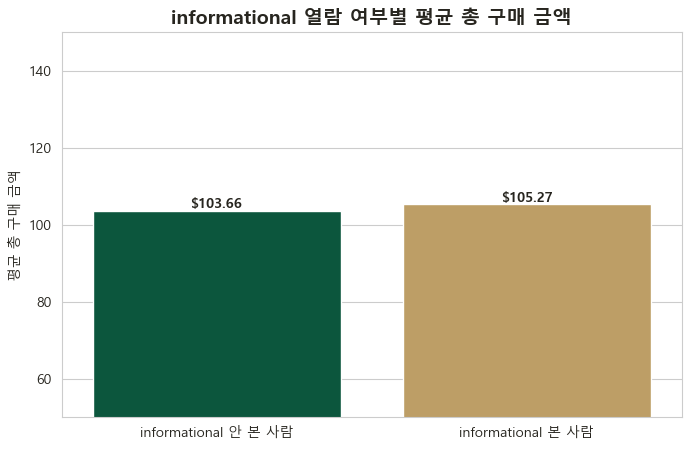

In [51]:
# informational 본 사람 vs 안 본 사람 시각화
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=info_view_compare,
    x='info_viewed_flag',
    y='평균총구매금액',
    palette=[SB_GREEN, SB_GOLD]
)

for i, v in enumerate(info_view_compare['평균총구매금액']):
    ax.text(i, v, f"${v:,.2f}", ha='center', va='bottom', color=SB_BLACK, fontweight='bold')

plt.title('informational 열람 여부별 평균 총 구매 금액', fontsize=14, fontweight='bold')
plt.xlabel('')
plt.ylabel('평균 총 구매 금액')
plt.ylim(50, 150)
plt.show()

### (bogo & discount) vs informational 매출 비교

In [52]:
# =========================================================
# [기존 코드 보존] (단위 불일치: 24시간 누적 평균 vs 1회 결제 평균)
# =========================================================
# # 완료 고객의 평균 결제액
# # 여기서는 bogo, discount completed 고객군(단일 + multi)의 평균 총 구매금액을 사용
# transaction_only = pd.read_csv("../../Data/transactions_260325.csv")
# 
# # reward completed와 연결된 거래
# completed_tx = transaction_only[
#     transaction_only['tx_offer_type'].isin(['bogo', 'discount', 'multi'])
# ].copy()
# 
# # 일반 거래
# normal_tx = transaction_only[
#     transaction_only['tx_offer_type'] == 'normal'
# ].copy()
# 
# completed_customer_avg_spend = completed_tx['amount'].mean()
# normal_customer_avg_spend = normal_tx['amount'].mean()
# 
# # informational 열람 후 24시간 내 평균 매출
# # info_24h_avg_revenue = info_24h_total_revenue / info_24h_purchase_cnt
# 
# # 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율
# # (완료 고객 평균 결제액 - informational 열람 후 24시간 평균 매출) / informational 열람 후 24시간 평균 매출 * 100
# revenue_lift_rate = (
#     (completed_customer_avg_spend - info_24h_avg_revenue) / info_24h_avg_revenue * 100
#     if info_24h_avg_revenue > 0 else np.nan
# )
# 
# print("=" * 60)
# print("[기존] 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율")
# print("=" * 60)
# print(f"completed 거래 고객 평균 결제액: ${completed_customer_avg_spend:,.2f}")
# print(f"일반 거래 고객 평균 결제액: ${normal_customer_avg_spend:,.2f}")
# print(f"informational 열람 후 24시간 평균 매출: ${info_24h_avg_revenue:,.2f}")
# print(f"정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율: {revenue_lift_rate:,.2f}%\n")

# =============================================================
# [기존 결과] [정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율]
# =============================================================
# completed 거래 고객 평균 결제액: $20.14
# 일반 거래 고객 평균 결제액: $10.70
# informational 열람 후 24시간 평균 매출: $16.78
# 정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율: 20.02%


# =========================================================
# [수정된 로직] 모든 기준을 '건당 1회 평균 결제액(AOV)'으로 통일
# =========================================================

# 1. BOGO, Discount 완료(사용) 거래 및 일반 거래 건당 평균 결제액
# (이 부분은 파일 경로만 맞다면 기존 로직과 동일하여 그대로 유지합니다)
transaction_only = pd.read_csv("../../Data/transactions_260325.csv") # 경로 확인 필요

completed_tx = transaction_only[
    transaction_only['tx_offer_type'].isin(['bogo', 'discount', 'multi'])
].copy()

normal_tx = transaction_only[
    transaction_only['tx_offer_type'] == 'normal'
].copy()

completed_tx_aov = completed_tx['amount'].mean()
normal_tx_aov = normal_tx['amount'].mean()


# 2. Informational 열람 후 24시간 내 발생한 거래들의 건당 평균 결제액(AOV) 구하기
# info_txn_merge 데이터프레임에서 실제 24시간 내 발생한 거래만 필터링
valid_info_txns = info_txn_merge[info_txn_merge['txn_within_24h'] == True].copy()

# 하나의 영수증(결제)이 여러 번의 열람 이벤트에 중복 카운트되는 것을 방지
unique_info_txns = valid_info_txns.drop_duplicates(subset=['customer_id', 'txn_time'])

# 인포메이션 오퍼의 영향을 받은 1회 결제당 평균 금액
info_24h_tx_aov = unique_info_txns['amount'].mean()


# 3. 새로운 매출 증대율 계산
new_revenue_lift_rate = (
    (completed_tx_aov - info_24h_tx_aov) / info_24h_tx_aov * 100
    if info_24h_tx_aov > 0 else np.nan
)

print("=" * 60)
print("[수정] 오퍼 유형별 건당 객단가(AOV) 및 매출 증대율")
print("=" * 60)
print(f"일반 거래(normal) 평균 객단가: ${normal_tx_aov:,.2f}")
print(f"informational 열람 후 24시간 내 거래 평균 객단가: ${info_24h_tx_aov:,.2f}")
print(f"bogo/discount 완료(사용) 거래 평균 객단가: ${completed_tx_aov:,.2f}")
print("-" * 60)
print(f"정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: {new_revenue_lift_rate:,.2f}%")

# =========================================================
# KPI DataFrame 업데이트 부분
# =========================================================
# info_kpi_df도 수정된 변수명에 맞게 업데이트
# info_kpi_df.loc[info_kpi_df['지표'] == '열람 후 24시간 내 평균 구매 금액', '값'] = round(info_24h_tx_aov, 2)
# info_kpi_df.loc[info_kpi_df['지표'] == '정보성 오퍼 열람 고객 대비 완료 고객 매출 증대율', '값'] = round(new_revenue_lift_rate, 2) if pd.notna(new_revenue_lift_rate) else np.nan

[수정] 오퍼 유형별 건당 객단가(AOV) 및 매출 증대율
일반 거래(normal) 평균 객단가: $10.70
informational 열람 후 24시간 내 거래 평균 객단가: $12.95
bogo/discount 완료(사용) 거래 평균 객단가: $20.14
------------------------------------------------------------
정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율: 55.48%


### informational KPI

In [53]:
# informational KPI 표 정리
info_kpi_df = pd.DataFrame({
    '지표': [
        '발송 수',
        '열람 수',
        '열람율',
        '열람 후 24시간 내 구매가 있었던 열람 수',
        '열람 후 24시간 내 구매 전환율',
        '열람 후 24시간 내 평균 구매 금액',
        'bogo/discount 완료(사용) 거래 평균 객단가',
        '정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율'
    ],
    '값': [
        info_received_cnt,
        info_viewed_cnt,
        round(info_view_rate * 100, 2),
        int(info_24h_purchase_cnt),
        round(info_24h_conversion_rate * 100, 2),
        round(info_24h_tx_aov, 2),
        round(completed_tx_aov, 2),
        round(new_revenue_lift_rate, 2) if pd.notna(new_revenue_lift_rate) else np.nan
    ]
})

display(info_kpi_df)

,지표,값
0,발송 수,15235.00
1,열람 수,9952.00
2,열람율,65.32
3,열람 후 24시간 내 구매가 있었던 열람 수,4254.00
4,열람 후 24시간 내 구매 전환율,42.75
5,열람 후 24시간 내 평균 구매 금액,12.95
6,bogo/discount 완료(사용) 거래 평균 객단가,20.14
7,정보성 오퍼 대비 보상형 오퍼(bogo/discount)의 객단가 증대율,55.48


### 요약

In [54]:
# 요약 표
summary_df = pd.DataFrame({
    '구분': [
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '전략적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        '우연적 전환 퍼널',
        'Informational',
        'Informational',
        'Informational'
    ],
    '지표': [
        '발송 수',
        '열람율',
        '전략적 전환율',
        '낭비된 완료 수',
        '낭비된 리워드 금액',
        '낭비된 리워드 비율',
        '발송 수',
        '열람율',
        '24시간 내 구매 전환율'
    ],
    '값': [
        received_cnt,
        round(view_rate * 100, 2),
        round(strategic_conversion_rate * 100, 2),
        wasted_completed_cnt,
        round(wasted_reward_amt, 2),
        round(wasted_reward_rate * 100, 2),
        info_received_cnt,
        round(info_view_rate * 100, 2),
        round(info_24h_conversion_rate * 100, 2)
    ]
})

display(summary_df)

,구분,지표,값
0,전략적 전환 퍼널,발송 수,61042.00
1,전략적 전환 퍼널,열람율,76.48
2,전략적 전환 퍼널,전략적 전환율,38.19
3,우연적 전환 퍼널,낭비된 완료 수,9850.00
4,우연적 전환 퍼널,낭비된 리워드 금액,48287.00
5,우연적 전환 퍼널,낭비된 리워드 비율,29.67
6,Informational,발송 수,15235.00
7,Informational,열람율,65.32
8,Informational,24시간 내 구매 전환율,42.75


In [55]:
offer_instance.to_csv('../../Data/offer_instance_260326.csv', index=False, encoding='utf-8-sig')